# Street networks and urban morphology
This tutorial explores network analysis using open source GIS libraries in the `pysal` family. Specifically, we'll explore the morphology of an urban built environment including various kinds of connectivty structures.

The tutorial is based on the [Simplified detection of urban types](https://docs.momepy.org/stable/examples/clustering.html) tutorial by Martin Fleishmann.

## Learning Outcomes
By the end of this tutorial, you should be able to:
1) Create, visualize, and analyze network objects.
2) Interpret network attributes such as connectivity and proximity.
3) Identify clusters of similar network features.

## Set up
To replicate this workflow, load the notebook in whatever platform you want to use (e.g. add it to a project in ArcGIS Pro, open it in Jupyter Notebooks on your local machine, or open it in a cloud environment like [ArcGIS Online](https://www.arcgis.com/index.html) or [Google Colab](https://colab.research.google.com/)).

You might need to install some of the libraries used in the workflow. If that's the case, you can use the ! pip install notation described below.

In [1]:
import geopandas
import libpysal
import matplotlib.pyplot as plt
import momepy
import osmnx
import pandas
from bokeh.io import output_notebook
from bokeh.plotting import show
from clustergram import Clustergram

In [ ]:
! pip install momepy
! pip install osmnx
! pip install clustergram

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.1 MB/s eta 0:00:00


## Load data
First we'll load and clean data from Open Street Map, including buildings and streets. I'll use data from a relatively small city just to keep the workflow manageable. You can customize the location and CRS as desired.

In [2]:
# define location and CRS
place = "Schenectady, NY, USA"
local_crs = 32618

In [3]:
# query building data
buildings = osmnx.features_from_place(place, tags={"building": True})

In [4]:
# and view a sample
buildings.head()

geometry addr:state building ele  \
element id                                                              
node    368044661  POINT (-73.93889 42.81639)         NY      yes  74   
        368044882  POINT (-73.92667 42.81528)         NY      yes  91   
        368044901   POINT (-73.9329 42.81519)         NY      yes  84   
        368044903     POINT (-73.92944 42.82)         NY      yes  80   
        368044917  POINT (-73.93162 42.81481)         NY      yes  88   

                  gnis:feature_id                   name         source  \
element id                                                                
node    368044661         2418118  Schenectady Boys Club  USGS Geonames   
        368044882         2426337     Class of 1884 Gate  USGS Geonames   
        368044901         2426332              Blue Gate  USGS Geonames   
        368044903         2426333          Brownell Gate  USGS Geonames   
        368044917         2426353             Payne Gate  USGS Geonames   

                     addr:city addr:country addr:housenumber  ... man_made  \
element id                                                    ...            
node    368044661          NaN          NaN              NaN  ...      NaN   
        368044882          NaN          NaN              NaN  ...      NaN   
        368044901          NaN          NaN              NaN  ...      NaN   
        368044903          NaN          NaN              NaN  ...      NaN   
        368044917  Schenectady           US              807  ...      NaN   

                  emergency disused building:part capacity building:flats  \
element id                                                                  
node    368044661       NaN     NaN           NaN      NaN            NaN   
        368044882       NaN     NaN           NaN      NaN            NaN   
        368044901       NaN     NaN           NaN      NaN            NaN   
        368044903       NaN     NaN           NaN      NaN            NaN   
        368044917       NaN     NaN           NaN      NaN            NaN   

                  swimming_pool architect owner start  
element id                                             
node    368044661           NaN       NaN   NaN   NaN  
        368044882           NaN       NaN   NaN   NaN  
        368044901           NaN       NaN   NaN   NaN  
        368044903           NaN       NaN   NaN   NaN  
        368044917           NaN       NaN   NaN   NaN  

[5 rows x 161 columns]

In [5]:
# see the data structure
buildings.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 17579 entries, ('node', np.int64(368044661)) to ('way', np.int64(1534027077))
Columns: 161 entries, geometry to start
dtypes: geometry(1), object(160)
memory usage: 22.8+ MB


In [6]:
# clean objects that are not proper polygons
# check geometry type
buildings.geom_type.value_counts()

,count
Polygon,17573
Point,6


In [7]:
# drop non-polygon objects
buildings = buildings[buildings.geom_type == "Polygon"].reset_index(drop=True)

# and double check
buildings.geom_type.value_counts()

,count
Polygon,17573


In [8]:
# and re-project the data
buildings = buildings[["geometry"]].to_crs(local_crs)
buildings.head()

,geometry
0,"POLYGON ((586823.368 4740514.181, 586849.338 4..."
1,"POLYGON ((587206.019 4740930.371, 587215.829 4..."
2,"POLYGON ((587252.764 4741029.81, 587262.526 47..."
3,"POLYGON ((586856.914 4740491.747, 586880.722 4..."
4,"POLYGON ((589083.278 4740828.703, 589077.555 4..."


Now we'll also load the street data. Since we're doing network analysis, we'll load it as a graph dataset that is then converted into a geodata frame.

In [9]:
# load streets
# query the data
osm_graph = osmnx.graph_from_place(place, network_type="drive")

# change projection
osm_graph = osmnx.projection.project_graph(osm_graph, to_crs=local_crs)

# convert to a graph object
streets = osmnx.graph_to_gdfs(
    osmnx.convert.to_undirected(osm_graph),
    nodes=False,
    edges=True,
    node_geometry=False,
    fill_edge_geometry=True,
).reset_index(drop=True)

# view some results
streets.head()

,osmid,highway,lanes,maxspeed,name,ref,oneway,reversed,length,from,to,geometry,bridge,access,tunnel,junction
0,133920288,primary,2,30 mph,State Street,NY 5,False,True,87.463176,42007468,41974273,"LINESTRING (587026.941 4740077.158, 587083.983...",NaN,NaN,NaN,NaN
1,133920288,primary,2,30 mph,State Street,NY 5,False,False,18.420048,444678926,41974273,"LINESTRING (587096.235 4739997.068, 587083.983...",NaN,NaN,NaN,NaN
2,5642029,residential,NaN,30 mph,Hulett Street,NaN,False,True,147.371202,41974275,41974273,"LINESTRING (586973.609 4739913.01, 587020.164 ...",NaN,NaN,NaN,NaN
3,5644795,residential,NaN,30 mph,Grove Place,NaN,False,True,140.850074,42007469,42007468,"LINESTRING (587132.36 4740170.74, 587064.804 4...",NaN,NaN,NaN,NaN
4,133920288,primary,2,30 mph,State Street,NY 5,False,True,137.405513,42048113,42007468,"LINESTRING (586934.414 4740178.802, 586950.957...",NaN,NaN,NaN,NaN


In [10]:
# and some processing to improve network topology
streets = momepy.remove_false_nodes(streets)
streets = streets[["geometry"]]
streets.head()

/tmp/ipykernel_31215/1144264927.py:2: FutureWarning: `remove_false_nodes` is deprecated and will be removed in momepy 1.0. The function has been improved and moved to the `neatnet` package and can be used as `neatnet.remove_interstitial_nodes`. See https://uscuni.org/neatnet for details.
  streets = momepy.remove_false_nodes(streets)


,geometry
0,"LINESTRING (587026.941 4740077.158, 587083.983..."
1,"LINESTRING (587096.235 4739997.068, 587083.983..."
2,"LINESTRING (586973.609 4739913.01, 587020.164 ..."
3,"LINESTRING (587132.36 4740170.74, 587064.804 4..."
4,"LINESTRING (586934.414 4740178.802, 586950.957..."


## Generate morphology features
After loading the data, we'll `momepy` to create the urban morphology. A lot of the workflow that follows hinges on a 'tessallation' layer that is drawn around each building. The tessellation allows us to create a continuous surface which can then be used to build various data and spatial join back to the street and building objects that interest us.

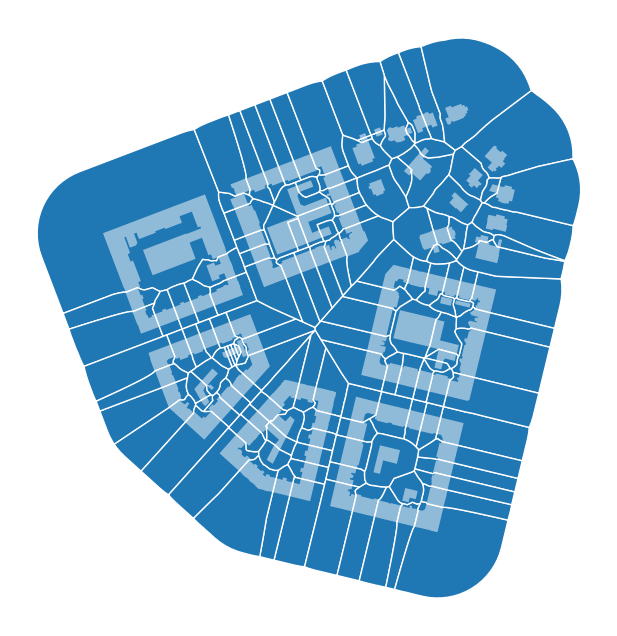

#### Clean up buildings

In [11]:
# buffer the buildings
limit = momepy.buffered_limit(buildings, "adaptive")


In [12]:
# create tessellation for comparison
tessellation = momepy.morphological_tessellation(buildings, clip=limit)

In [13]:
# verify data quality
collapsed, _ = momepy.verify_tessellation(tessellation, buildings)

/tmp/ipykernel_31215/3049798227.py:2: UserWarning: Tessellation contains MultiPolygon elements. Initial objects should  be edited. Index of affected elements: [330, 334, 579, 660, 661, 891, 1047, 1342, 1725, 2838, 2920, 3173, 3419, 3547, 3561, 3891, 4206, 4746, 5270, 5482, 6093, 6212, 6500, 7629, 7996, 8309, 8325, 8326, 8327, 8328, 8329, 8330, 9388, 9389, 9620, 10710, 10711, 10712, 10713, 11000, 11347, 11416, 12232, 12686, 13077, 13279, 13281, 13282, 13283, 13378, 13628, 14979, 15713, 15796, 15805, 15863, 17086, 17123, 17265].
  collapsed, _ = momepy.verify_tessellation(tessellation, buildings)


In [14]:
# drop overlapping buildings
buildings = buildings.drop(collapsed)
limit = momepy.buffered_limit(buildings, "adaptive")
tessellation = momepy.morphological_tessellation(buildings, clip=limit)

In [15]:
# and double check results
tessellation.shape[0] == buildings.shape[0]

True

#### Clean up streets

In [16]:
# link unique IDs of streets to nearby buildings
buildings["street_index"] = momepy.get_nearest_street(
    buildings, streets, max_distance=100
)
buildings

,geometry,street_index
0,"POLYGON ((586823.368 4740514.181, 586849.338 4...",908.0
1,"POLYGON ((587206.019 4740930.371, 587215.829 4...",86.0
2,"POLYGON ((587252.764 4741029.81, 587262.526 47...",228.0
3,"POLYGON ((586856.914 4740491.747, 586880.722 4...",908.0
4,"POLYGON ((589083.278 4740828.703, 589077.555 4...",1615.0
...,...,...
17568,"POLYGON ((589147.432 4735891.731, 589144.733 4...",1747.0
17569,"POLYGON ((589128.106 4735874.5, 589136.552 473...",1747.0
17570,"POLYGON ((589123.042 4735866.827, 589128.589 4...",1747.0
17571,"POLYGON ((589114.363 4735857.119, 589116.134 4...",1747.0


In [17]:
# link network index to buildings
tessellation["street_index"] = buildings["street_index"]

## Measuring urban morphology
Next we'll explore some dimensions of the built environment. They include:
- Basic dimensions for polygons such as area and elongation (how compact or not)
- Basic dimensions for lines such as length and linearity (how compact or extended)
- Spatial proximity of features in the network
- Connectivity of nodes and other features in the network



#### Dimensions
Basic dimensions of the built environment include attributes such as area and length, as well as more specific geometric inidicators such as elongation (is it like a square or a long rectangle), linearity (how straight or not is the linear trend of the object), and convexity (the relative compactness of the object around its center).

In [18]:
# calculate area/length
buildings["building_area"] = buildings.area
tessellation["tess_area"] = tessellation.area
streets["length"] = streets.length

In [19]:
# calculate shape attributes
buildings["eri"] = momepy.equivalent_rectangular_index(buildings)
buildings["elongation"] = momepy.elongation(buildings)
tessellation["convexity"] = momepy.convexity(tessellation)
streets["linearity"] = momepy.linearity(streets)

Text(0.5, 1.0, 'Elongation')

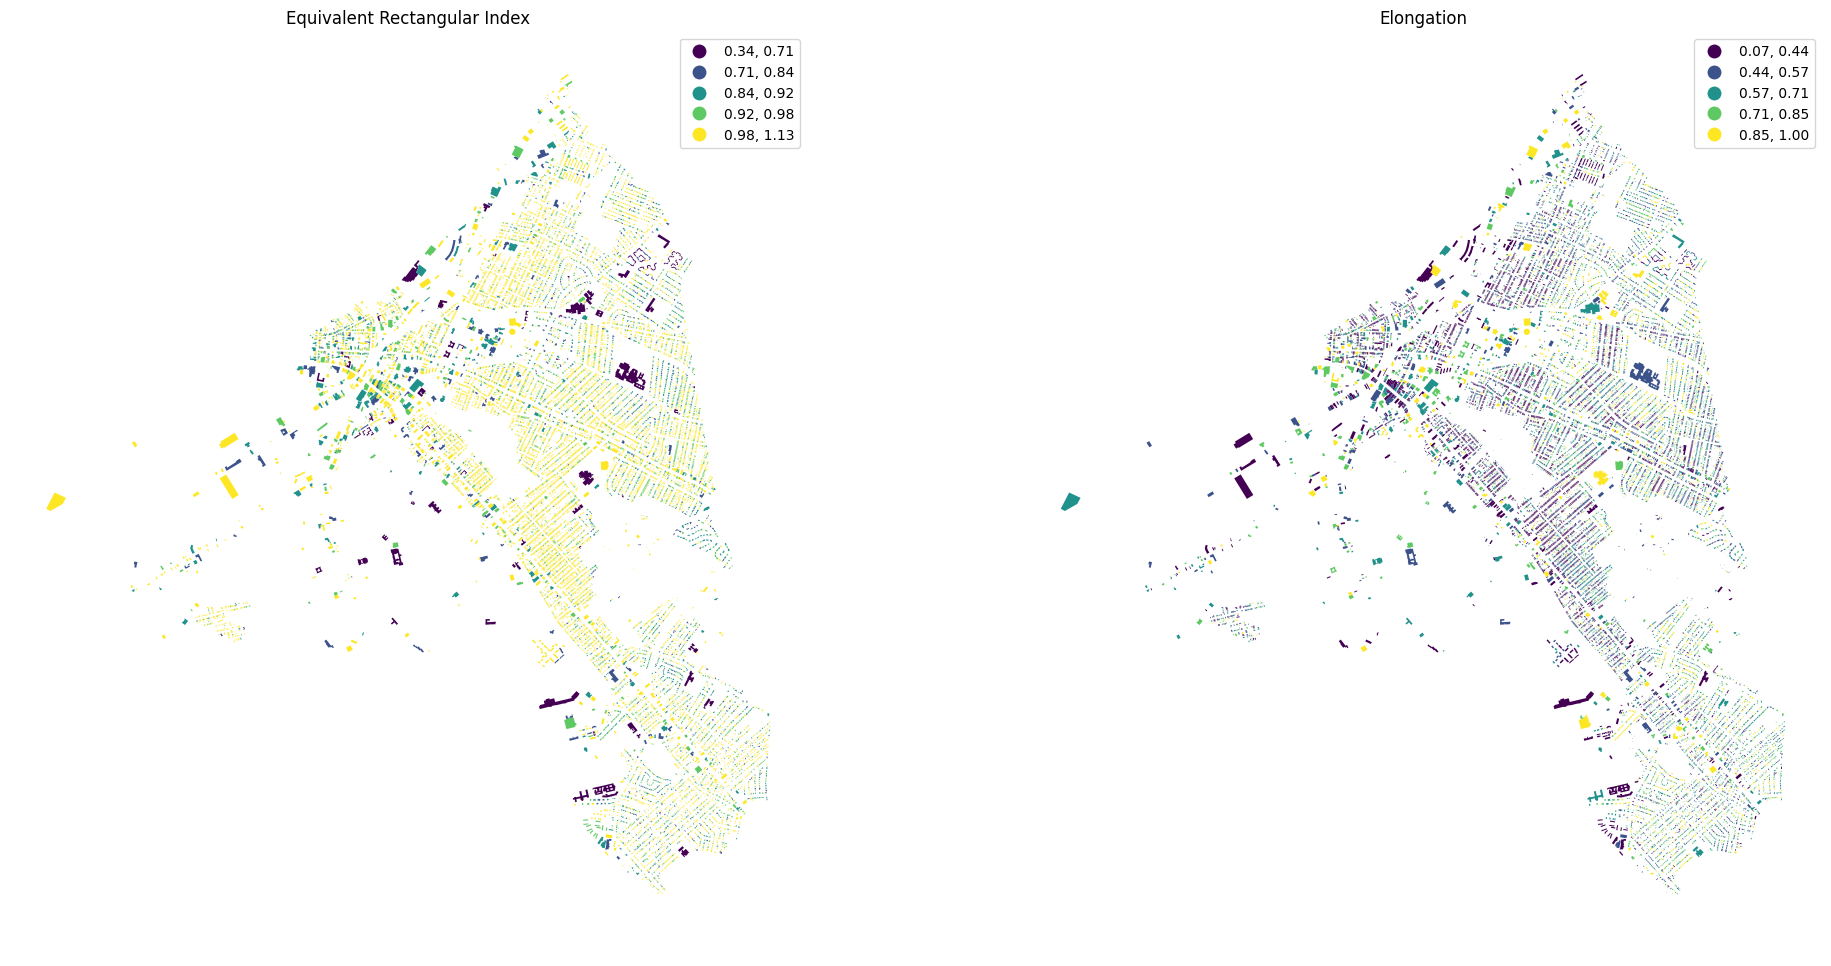

In [20]:
# plot buildings
# create a plot space for two figures
fig, ax = plt.subplots(1, 2, figsize=(24, 12))

# define both maps
buildings.plot("eri", ax=ax[0], scheme="natural_breaks", legend=True)
buildings.plot("elongation", ax=ax[1], scheme="natural_breaks", legend=True)

# add maps and titles to plot space
ax[0].set_axis_off()
ax[0].set_title("Equivalent Rectangular Index")
ax[1].set_axis_off()
ax[1].set_title("Elongation")

Text(0.5, 1.0, 'Linearity')

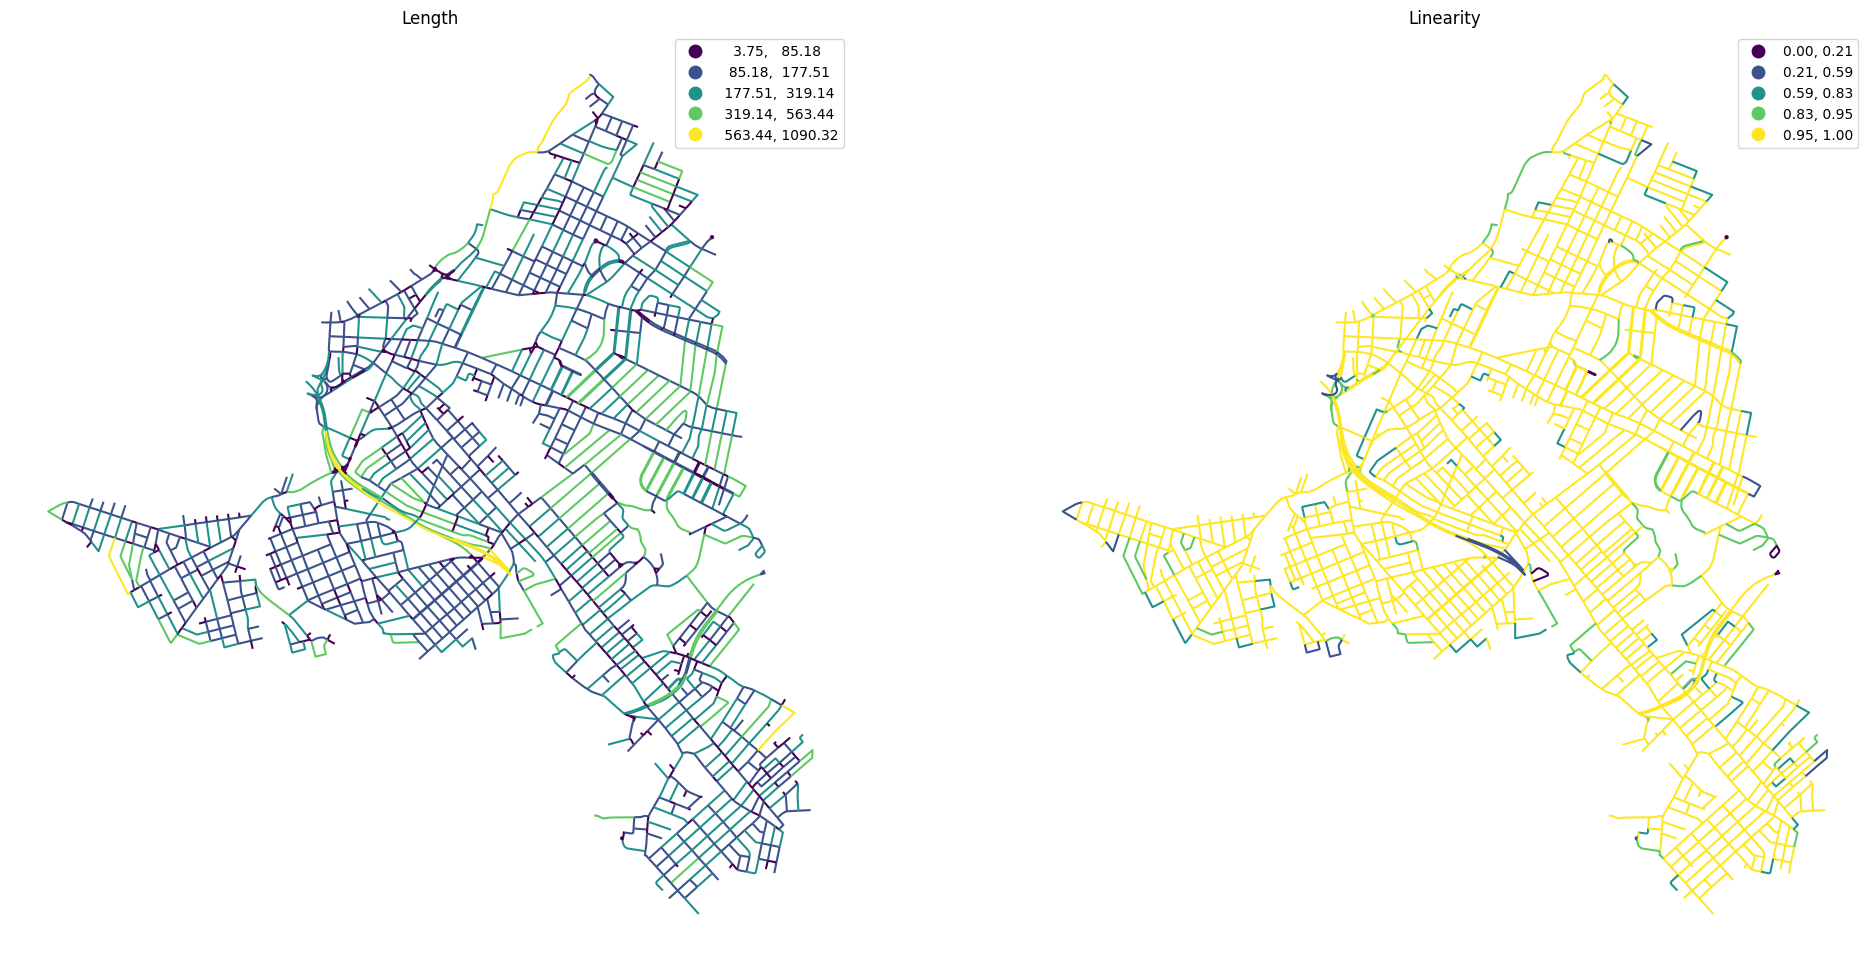

In [21]:
# plot streets
# create a plot space for two figures
fig, ax = plt.subplots(1, 2, figsize=(24, 12))

# define both maps
streets.plot("length", ax=ax[0], scheme="natural_breaks", legend=True)
streets.plot("linearity", ax=ax[1], scheme="natural_breaks", legend=True)

# add maps and titles to plot space
ax[0].set_axis_off()
ax[0].set_title("Length")
ax[1].set_axis_off()
ax[1].set_title("Linearity")

### Proximity metrics
Here we'll use a spatial matrix to assess how features relate to each other, with metrics such as distance to nearest neighbors, distance between buildings, and relative levels of adjacency.


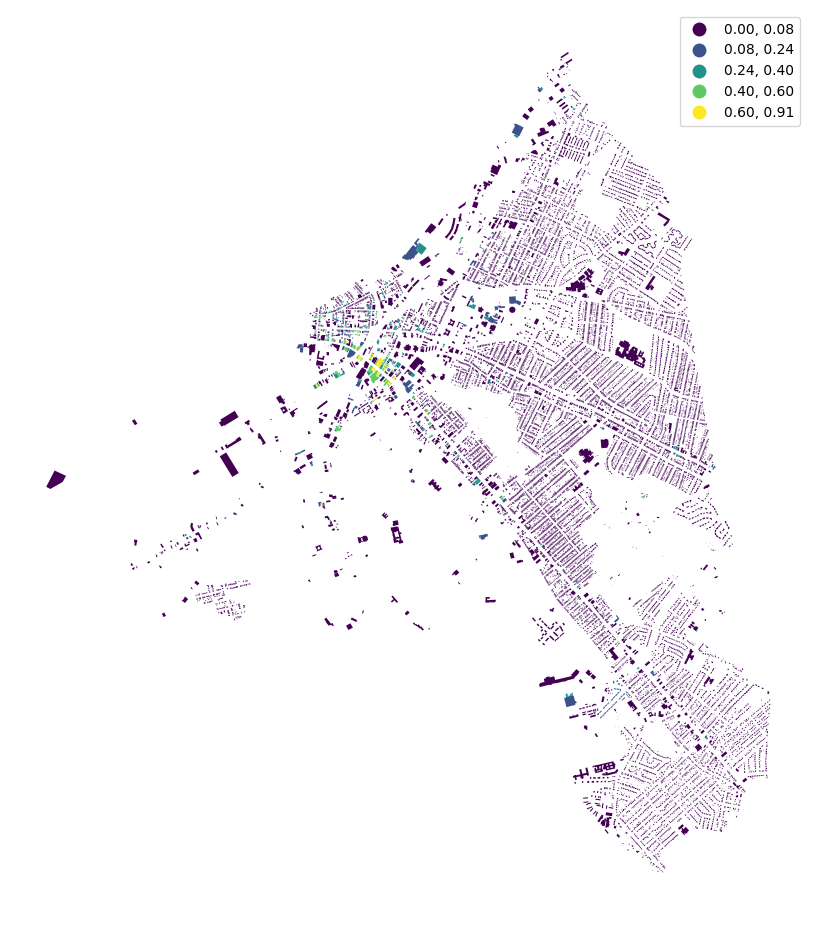

In [22]:
# find buildings that touch
buildings["shared_walls"] = momepy.shared_walls(buildings) / buildings.length
buildings.plot(
    "shared_walls", figsize=(12, 12), scheme="natural_breaks", legend=True
).set_axis_off()

In [23]:
# create a spatial graph
queen_1 = libpysal.graph.Graph.build_contiguity(tessellation, rook=False)

# and add to tessellation
tessellation["neighbors"] = momepy.neighbors(
    tessellation, queen_1, weighted=True
)
tessellation["covered_area"] = queen_1.describe(tessellation.area)["sum"]
buildings["neighbor_distance"] = momepy.neighbor_distance(buildings, queen_1)

buildings.head()

,geometry,street_index,building_area,eri,elongation,shared_walls,neighbor_distance
0,"POLYGON ((586823.368 4740514.181, 586849.338 4...",908.0,1598.281826,0.961690,0.929653,0.221743,23.621246
1,"POLYGON ((587206.019 4740930.371, 587215.829 4...",86.0,2460.126299,0.551635,0.792201,0.000000,65.016133
2,"POLYGON ((587252.764 4741029.81, 587262.526 47...",228.0,2465.090795,0.549844,0.792358,0.000000,66.931271
3,"POLYGON ((586856.914 4740491.747, 586880.722 4...",908.0,1007.180685,0.998955,0.753616,0.287471,33.045408
4,"POLYGON ((589083.278 4740828.703, 589077.555 4...",1615.0,36271.832064,0.340734,0.530468,0.000000,66.990551


Text(0.5, 1.0, 'Covered Area')

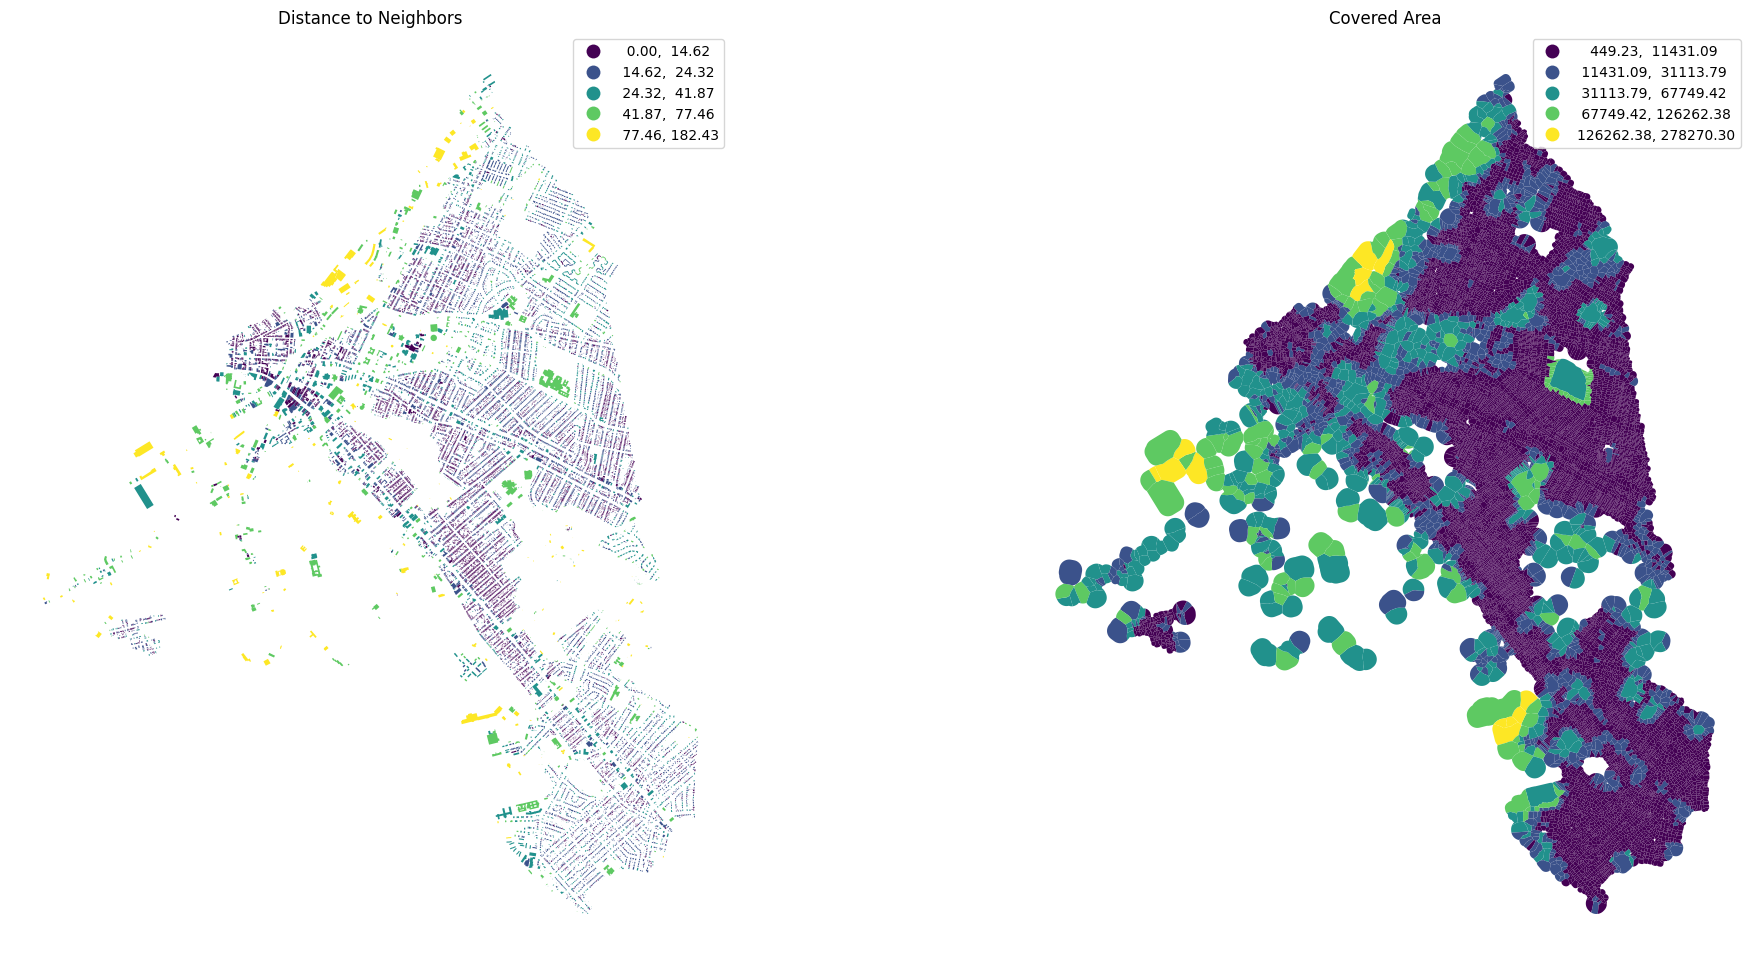

In [24]:
# plot proximity metrics
# define plot space
fig, ax = plt.subplots(1, 2, figsize=(24, 12))

# create plots
buildings.plot(
    "neighbor_distance", ax=ax[0], scheme="natural_breaks", legend=True
)
tessellation.plot(
    "covered_area", ax=ax[1], scheme="natural_breaks", legend=True
)

# add maps to plot space
ax[0].set_axis_off()
ax[0].set_title("Distance to Neighbors")
ax[1].set_axis_off()
ax[1].set_title("Covered Area")

In [25]:
# and calculate contiguity metrics
# create matrix
queen_3 = queen_1.higher_order(3)

# join to buildings
buildings_q1 = libpysal.graph.Graph.build_contiguity(buildings, rook=False)

buildings["interbuilding_distance"] = momepy.mean_interbuilding_distance(
    buildings, queen_1, queen_3
)
buildings["adjacency"] = momepy.building_adjacency(buildings_q1, queen_3)

buildings.head()

/usr/local/lib/python3.12/dist-packages/momepy/functional/_distribution.py:375: RuntimeWarning: invalid value encountered in scalar divide
  mean_distances[i] = sub_matrix.sum() / sub_matrix.nnz


,geometry,street_index,building_area,eri,elongation,shared_walls,neighbor_distance,interbuilding_distance,adjacency
0,"POLYGON ((586823.368 4740514.181, 586849.338 4...",908.0,1598.281826,0.961690,0.929653,0.221743,23.621246,31.585526,0.909091
1,"POLYGON ((587206.019 4740930.371, 587215.829 4...",86.0,2460.126299,0.551635,0.792201,0.000000,65.016133,32.459890,0.975610
2,"POLYGON ((587252.764 4741029.81, 587262.526 47...",228.0,2465.090795,0.549844,0.792358,0.000000,66.931271,22.210070,0.965517
3,"POLYGON ((586856.914 4740491.747, 586880.722 4...",908.0,1007.180685,0.998955,0.753616,0.287471,33.045408,28.087078,0.937500
4,"POLYGON ((589083.278 4740828.703, 589077.555 4...",1615.0,36271.832064,0.340734,0.530468,0.000000,66.990551,17.042036,0.986111


Text(0.5, 1.0, 'Adjacency')

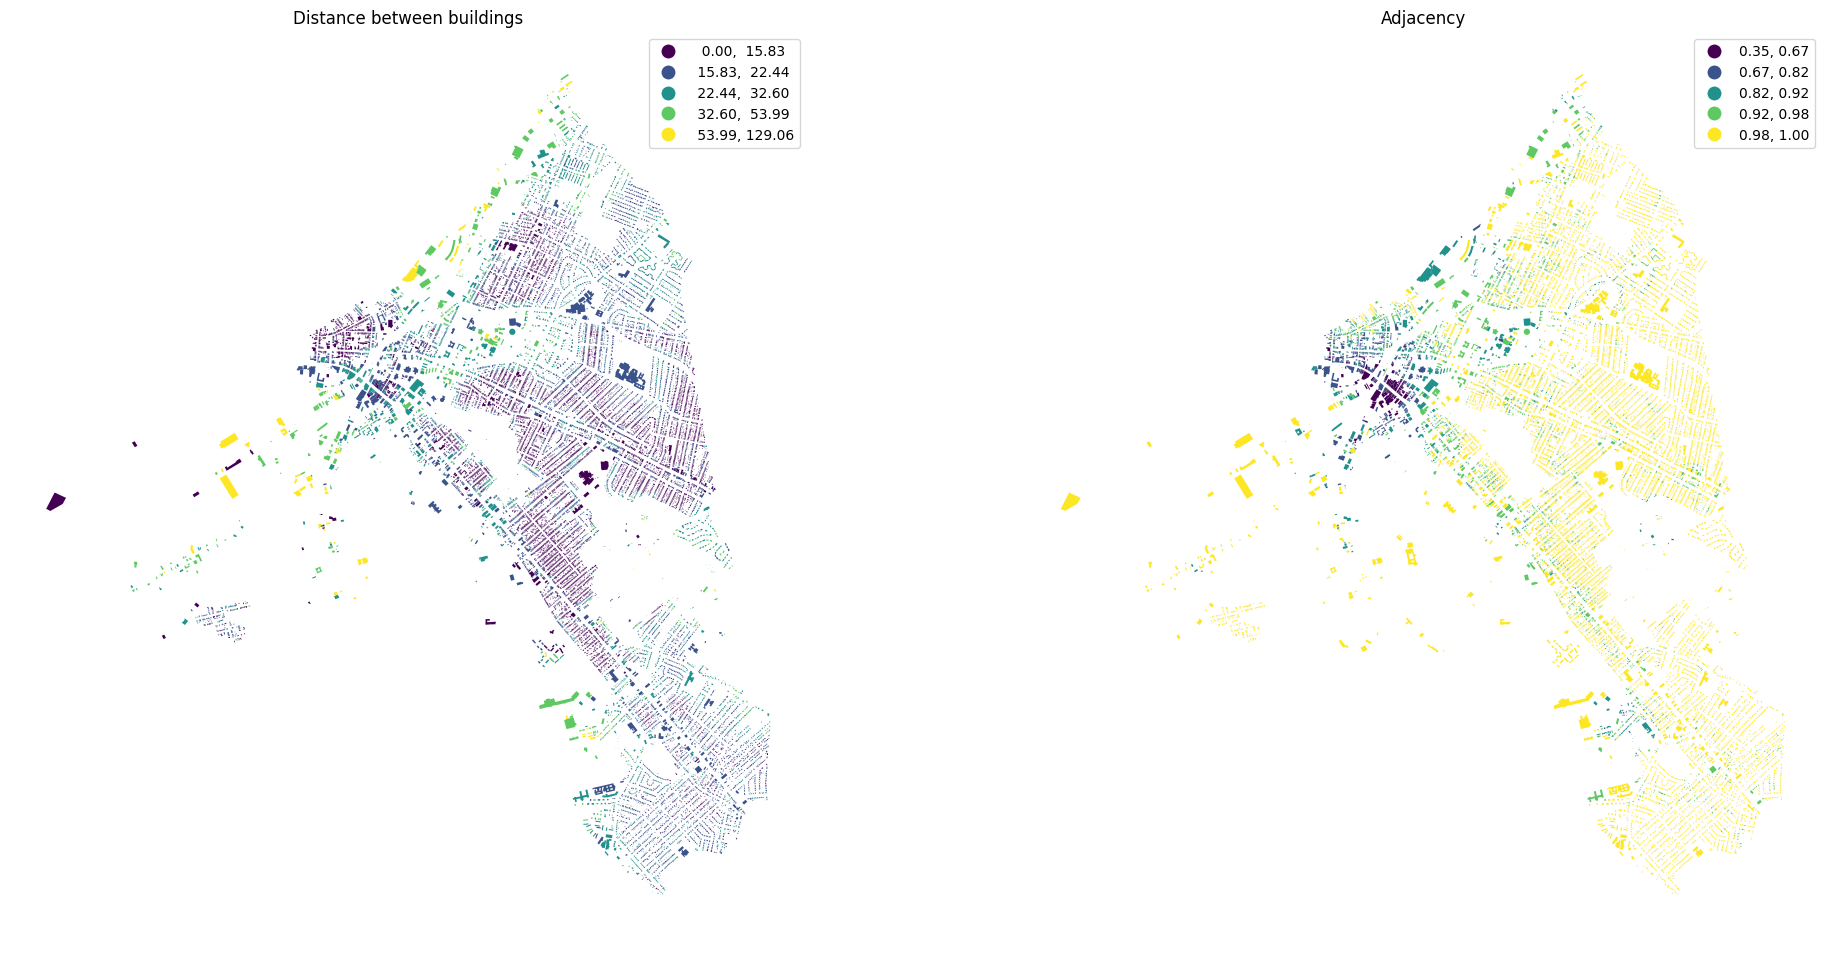

In [26]:
# plot contiguity metrics
fig, ax = plt.subplots(1, 2, figsize=(24, 12))

buildings.plot(
    "interbuilding_distance", ax=ax[0], scheme="natural_breaks", legend=True
)
buildings.plot("adjacency", ax=ax[1], scheme="natural_breaks", legend=True)

ax[0].set_axis_off()
ax[0].set_title("Distance between buildings")
ax[1].set_axis_off()
ax[1].set_title("Adjacency")

Now we'll connect building and street metrics to create a network profile.

In [27]:
# create a street profile based on local built environments
profile = momepy.street_profile(streets, buildings)

# and add it back to the street data
streets[profile.columns] = profile

streets.head()

,geometry,length,linearity,width,openness,width_deviation
0,"LINESTRING (587026.941 4740077.158, 587083.983...",87.483273,1.000000,33.075931,0.550000,3.783934
1,"LINESTRING (587096.235 4739997.068, 587083.983...",18.425412,1.000000,37.558685,0.833333,0.000000
2,"LINESTRING (586973.609 4739913.01, 587020.164 ...",147.490402,0.999944,18.692204,0.527778,6.403986
3,"LINESTRING (587132.36 4740170.74, 587064.804 4...",140.963638,1.000000,17.892373,0.529412,0.884766
4,"LINESTRING (586934.414 4740178.802, 586950.957...",137.450959,1.000000,26.362791,0.588235,1.270102


Text(0.5, 1.0, 'Street Opennness')

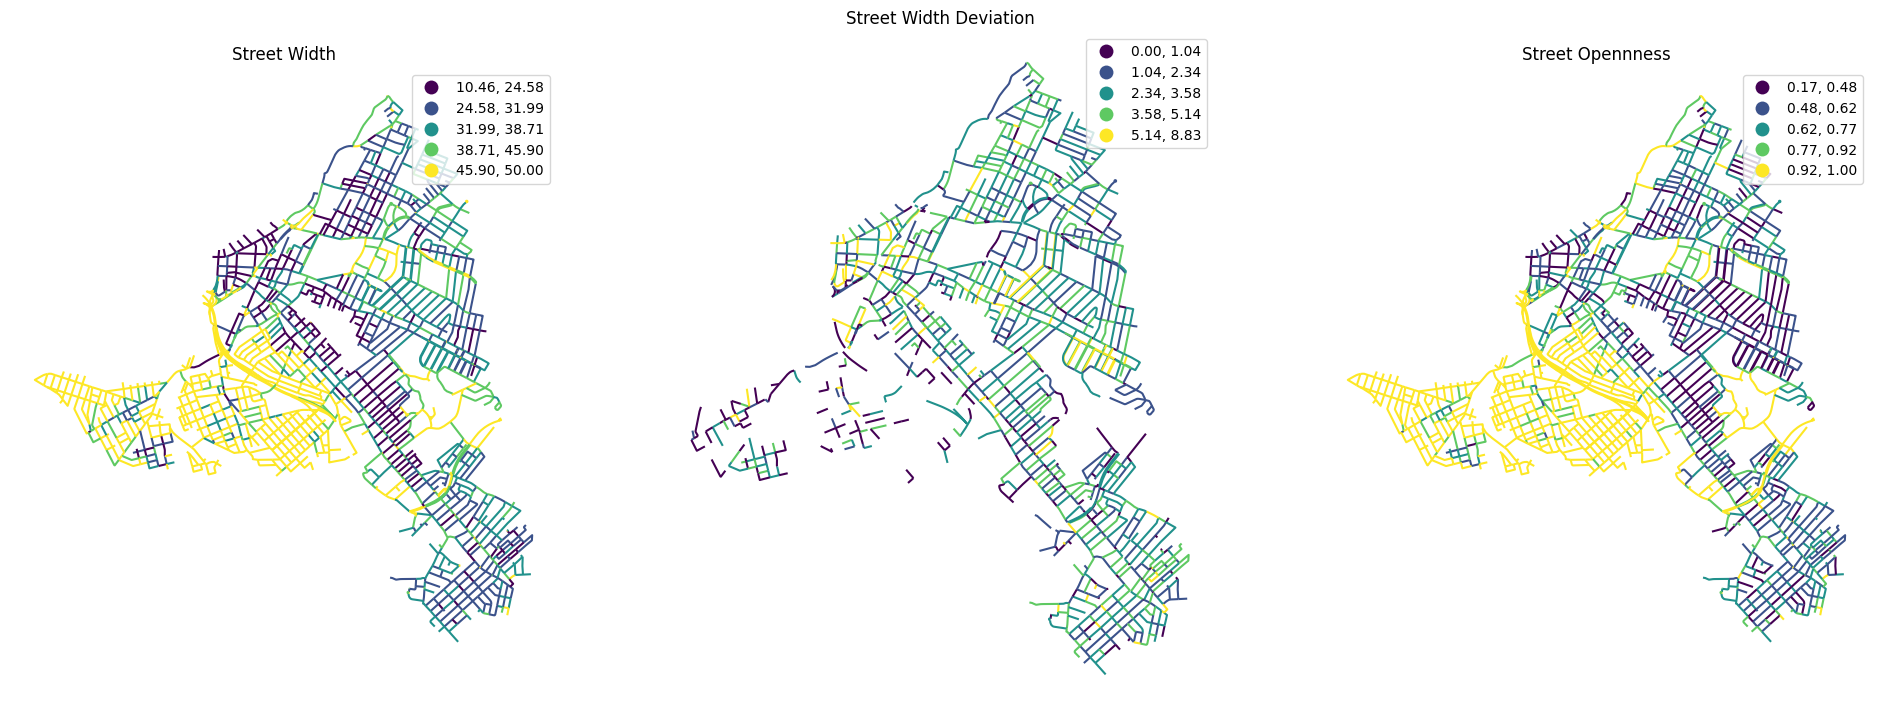

In [28]:
# and plot street profiles
fig, ax = plt.subplots(1, 3, figsize=(24, 12))

streets.plot("width", ax=ax[0], scheme="natural_breaks", legend=True)
streets.plot("width_deviation", ax=ax[1], scheme="natural_breaks", legend=True)
streets.plot("openness", ax=ax[2], scheme="natural_breaks", legend=True)

ax[0].set_axis_off()
ax[0].set_title("Street Width")
ax[1].set_axis_off()
ax[1].set_title("Street Width Deviation")
ax[2].set_axis_off()
ax[2].set_title("Street Opennness")

#### Connectivity
Next we'll explore connectivity by defining nodes in the network and their relationship to other linear and polygon features.

In [29]:
# create a node graph
graph = momepy.gdf_to_nx(streets)

# build the nodes
graph = momepy.node_degree(graph)

# find network centrality
graph = momepy.closeness_centrality(graph, radius=400, distance="mm_len")

# find network meshedness (aka degree of overlap)
graph = momepy.meshedness(graph, radius=400, distance="mm_len")

nodes, edges = momepy.nx_to_gdf(graph)

  0%|          | 0/1424 [00:00<?, ?it/s]

  0%|          | 0/1424 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/mapclassify/classifiers.py:689: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 4.
  self._classify()


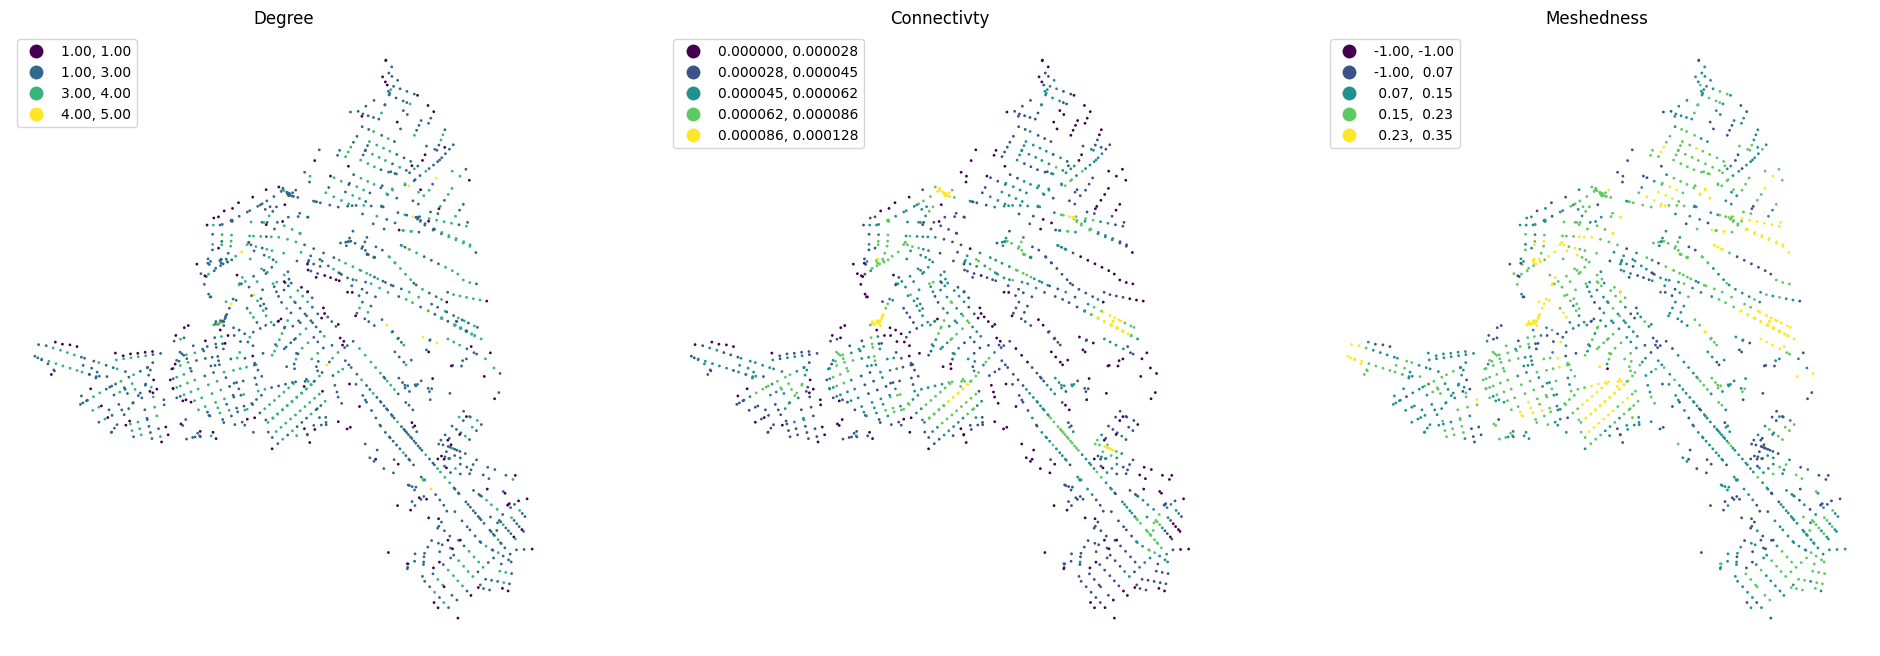

In [30]:
# plot nodes by connectivity
# define plot space
fig, ax = plt.subplots(1, 3, figsize=(24, 12))

# define maps
nodes.plot(
    "degree", ax=ax[0], scheme="natural_breaks", legend=True, markersize=1
)
nodes.plot(
    "closeness",
    ax=ax[1],
    scheme="natural_breaks",
    legend=True,
    markersize=1,
    legend_kwds={"fmt": "{:.6f}"},
)
nodes.plot(
    "meshedness", ax=ax[2], scheme="natural_breaks", legend=True, markersize=1
)

# add to plot space
ax[0].set_axis_off()
ax[0].set_title("Degree")
ax[1].set_axis_off()
ax[1].set_title("Connectivty")
ax[2].set_title("Meshedness")
ax[2].set_axis_off()

In [31]:
# Connect building edges to network
buildings["edge_index"] = momepy.get_nearest_street(buildings, edges)

# Connect buildigns to nodes
buildings["node_index"] = momepy.get_nearest_node(
    buildings, nodes, edges, buildings["edge_index"]
)

buildings.head()

,geometry,street_index,building_area,eri,elongation,shared_walls,neighbor_distance,interbuilding_distance,adjacency,edge_index,node_index
0,"POLYGON ((586823.368 4740514.181, 586849.338 4...",908.0,1598.281826,0.961690,0.929653,0.221743,23.621246,31.585526,0.909091,1342.0,723.0
1,"POLYGON ((587206.019 4740930.371, 587215.829 4...",86.0,2460.126299,0.551635,0.792201,0.000000,65.016133,32.459890,0.975610,155.0,76.0
2,"POLYGON ((587252.764 4741029.81, 587262.526 47...",228.0,2465.090795,0.549844,0.792358,0.000000,66.931271,22.210070,0.965517,167.0,76.0
3,"POLYGON ((586856.914 4740491.747, 586880.722 4...",908.0,1007.180685,0.998955,0.753616,0.287471,33.045408,28.087078,0.937500,1342.0,723.0
4,"POLYGON ((589083.278 4740828.703, 589077.555 4...",1615.0,36271.832064,0.340734,0.530468,0.000000,66.990551,17.042036,0.986111,908.0,472.0


In [32]:
# and join back to tessellation
tessellation[buildings.columns.drop(["geometry", "street_index"])] = (
    buildings.drop(columns=["geometry", "street_index"])
)
merged = tessellation.merge(
    edges.drop(columns="geometry"),
    left_on="edge_index",
    right_index=True,
    how="left",
)
merged = merged.merge(
    nodes.drop(columns="geometry"),
    left_on="node_index",
    right_index=True,
    how="left",
)

merged.head()

,geometry,street_index,tess_area,convexity,neighbors,covered_area,building_area,eri,elongation,shared_walls,...,width_deviation,mm_len,node_start,node_end,x,y,degree,closeness,meshedness,nodeID
0,"POLYGON ((586821.625 4740476.469, 586819.261 4...",908.0,3602.913574,0.818629,0.018676,46742.331866,1598.281826,0.961690,0.929653,0.221743,...,3.960250,219.322548,720,723,586821.963029,4.740582e+06,4,0.000052,0.171429,723
1,"POLYGON ((587212.906 4740858.021, 587204.604 4...",86.0,13644.476674,0.979651,0.020069,41881.530417,2460.126299,0.551635,0.792201,0.000000,...,5.899199,137.877825,71,76,587167.800746,4.740995e+06,3,0.000036,0.240000,76
2,"POLYGON ((587194 4741008.121, 587194.209 47410...",228.0,13727.919464,0.959054,0.025342,47916.844555,2465.090795,0.549844,0.792358,0.000000,...,3.104122,257.114015,76,201,587167.800746,4.740995e+06,3,0.000036,0.240000,76
3,"POLYGON ((586850.569 4740469.807, 586852.064 4...",908.0,3976.868828,0.989300,0.020857,55188.641919,1007.180685,0.998955,0.753616,0.287471,...,3.960250,219.322548,720,723,586821.963029,4.740582e+06,4,0.000052,0.171429,723
4,"POLYGON ((589249.196 4740534.651, 589248.858 4...",1615.0,100699.342501,0.962123,0.029361,57113.918539,36271.832064,0.340734,0.530468,0.000000,...,1.331274,440.374017,472,1163,589261.501918,4.740506e+06,4,0.000019,0.000000,472


In [33]:
# see variable structure
merged.columns

Index(['geometry', 'street_index', 'tess_area', 'convexity', 'neighbors',
       'covered_area', 'building_area', 'eri', 'elongation', 'shared_walls',
       'neighbor_distance', 'interbuilding_distance', 'adjacency',
       'edge_index', 'node_index', 'length', 'linearity', 'width', 'openness',
       'width_deviation', 'mm_len', 'node_start', 'node_end', 'x', 'y',
       'degree', 'closeness', 'meshedness', 'nodeID'],
      dtype='object')

## Assess clustered types within the network
This final section explores the overall properties of the network. We'll start with some data wrangling to rank each element of the network based on percentiles in the dimensions we calculated above. Then we'll use a cluster analysis method to identify groups of similar features in the network.

In [34]:
# create a percentile ranking table
percentiles = []
for column in merged.columns.drop(
    [
        "street_index",
        "node_index",
        "edge_index",
        "nodeID",
        "mm_len",
        "node_start",
        "node_end",
        "geometry",
    ]
):
    perc = momepy.percentile(merged[column], queen_3)
    perc.columns = [f"{column}_" + str(x) for x in perc.columns]
    percentiles.append(perc)

In [35]:
# and clean into a table
percentiles_joined = pandas.concat(percentiles, axis=1)
percentiles_joined.head()

,tess_area_25,tess_area_50,tess_area_75,convexity_25,convexity_50,convexity_75,neighbors_25,neighbors_50,neighbors_75,covered_area_25,...,y_75,degree_25,degree_50,degree_75,closeness_25,closeness_50,closeness_75,meshedness_25,meshedness_50,meshedness_75
focal,,,,,,,,,,,,,,,,,,,,,
0,1269.903882,2496.431778,3709.590444,0.872900,0.937031,0.971632,0.019061,0.028096,0.036228,14544.766484,...,4.740724e+06,3.0,4.0,4.0,0.000044,0.000053,0.000056,0.142857,0.162162,0.205128
1,773.930546,1269.125242,3248.786903,0.874915,0.932381,0.967914,0.024988,0.032468,0.043033,9051.950799,...,4.741232e+06,3.0,4.0,4.0,0.000033,0.000033,0.000037,0.129032,0.238095,0.238095
2,580.281654,785.112860,4066.949238,0.851125,0.929705,0.957425,0.022417,0.037525,0.043330,4884.484384,...,4.741237e+06,3.0,3.0,4.0,0.000033,0.000034,0.000040,0.179429,0.217391,0.238095
3,777.675098,1900.947862,3401.791387,0.871238,0.945875,0.971632,0.020383,0.032234,0.045404,9636.716490,...,4.740720e+06,3.0,4.0,4.0,0.000043,0.000053,0.000058,0.144180,0.163265,0.195122
4,508.802708,692.306211,878.775499,0.919581,0.955638,0.977714,0.043285,0.053421,0.062664,3424.725717,...,4.740903e+06,3.0,4.0,4.0,0.000021,0.000035,0.000050,0.000000,0.173913,0.279070


Text(0.5, 1.0, 'Lagged Convexity')

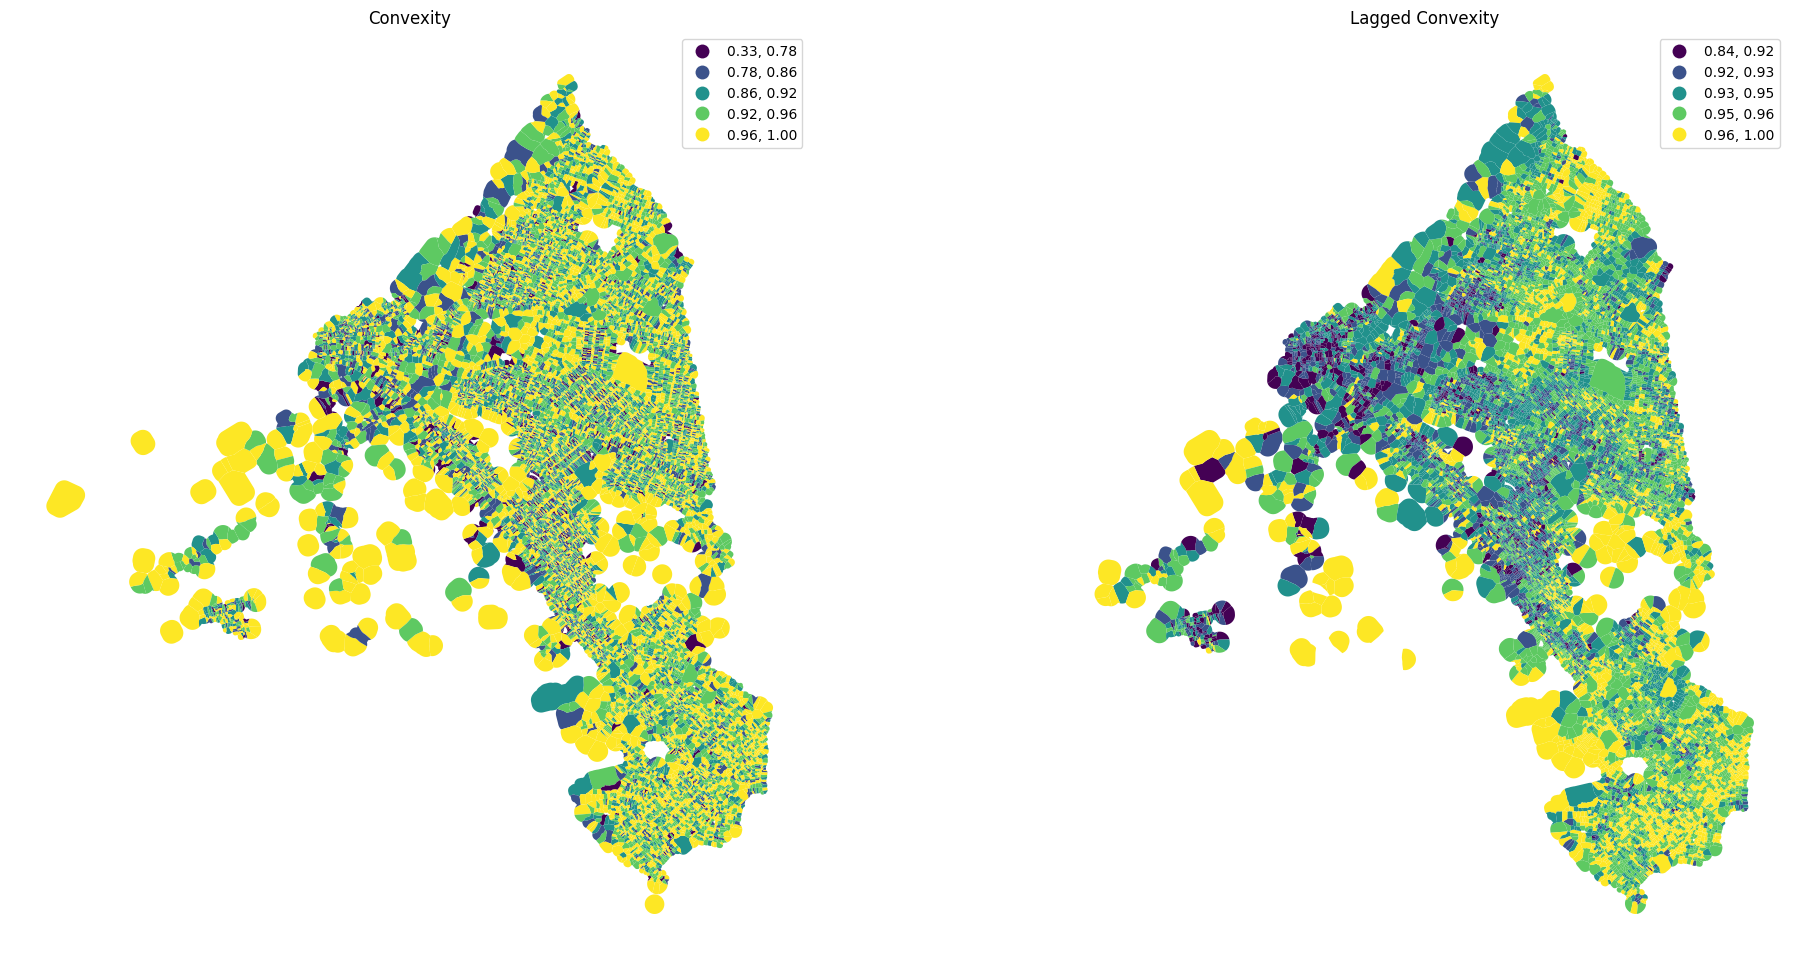

In [36]:
# visualize the actual data and a lag based on percentiles
fig, ax = plt.subplots(1, 2, figsize=(24, 12))

tessellation.plot("convexity", ax=ax[0], scheme="natural_breaks", legend=True)
merged.plot(
    percentiles_joined["convexity_50"].values,
    ax=ax[1],
    scheme="natural_breaks",
    legend=True,
)

ax[0].set_axis_off()
ax[0].set_title("Convexity")
ax[1].set_axis_off()
ax[1].set_title("Lagged Convexity")

#### Clustering

In [37]:
# first standardize the percentiles
standardized = (
    percentiles_joined - percentiles_joined.mean()
) / percentiles_joined.std()
standardized.head()

,tess_area_25,tess_area_50,tess_area_75,convexity_25,convexity_50,convexity_75,neighbors_25,neighbors_50,neighbors_75,covered_area_25,...,y_75,degree_25,degree_50,degree_75,closeness_25,closeness_50,closeness_75,meshedness_25,meshedness_50,meshedness_75
focal,,,,,,,,,,,,,,,,,,,,,
0,0.699502,1.145064,0.932473,-0.894575,-0.617340,-0.248524,-2.018768,-2.023520,-1.913497,2.097596,...,0.571230,-0.199255,1.015730,0.541369,0.358198,0.532442,0.371319,0.367187,0.246344,0.507098
1,0.232619,0.305985,0.742997,-0.829492,-0.896733,-0.660556,-1.517861,-1.681042,-1.506732,0.989470,...,0.847825,-0.199255,1.015730,0.541369,-0.382596,-0.703279,-0.690921,0.169547,1.371963,1.007363
2,0.050328,-0.024922,1.079413,-1.597771,-1.057505,-1.823059,-1.735134,-1.284890,-1.488997,0.148721,...,0.850510,-0.199255,-0.777119,0.541369,-0.382596,-0.631731,-0.541232,0.890024,1.065051,1.007363
3,0.236143,0.737946,0.805911,-0.948244,-0.086011,-0.248524,-1.907118,-1.699383,-1.365011,1.107441,...,0.569285,-0.199255,1.015730,0.541369,0.275911,0.532442,0.449315,0.386097,0.262697,0.355256
4,-0.016959,-0.088371,-0.231514,0.612942,0.500573,0.425605,0.028459,-0.039609,-0.333239,-0.145772,...,0.668513,-0.199255,1.015730,0.541369,-1.180318,-0.588727,0.040477,-1.675095,0.420537,1.629139


In [38]:
# now explore clustering structure
# calculate clusters up to k=12
cgram = Clustergram(range(1, 12), n_init=10, random_state=42)
cgram.fit(standardized.fillna(0))

show(cgram.bokeh())

K=1 skipped. Mean computed from data directly.
K=2 fitted in 1.509 seconds.
K=3 fitted in 1.611 seconds.
K=4 fitted in 1.885 seconds.
K=5 fitted in 2.037 seconds.
K=6 fitted in 1.964 seconds.
K=7 fitted in 3.735 seconds.
K=8 fitted in 9.853 seconds.
K=9 fitted in 7.614 seconds.
K=10 fitted in 3.669 seconds.
K=11 fitted in 4.623 seconds.


Text(0.5, 1.0, 'Building Clusters')

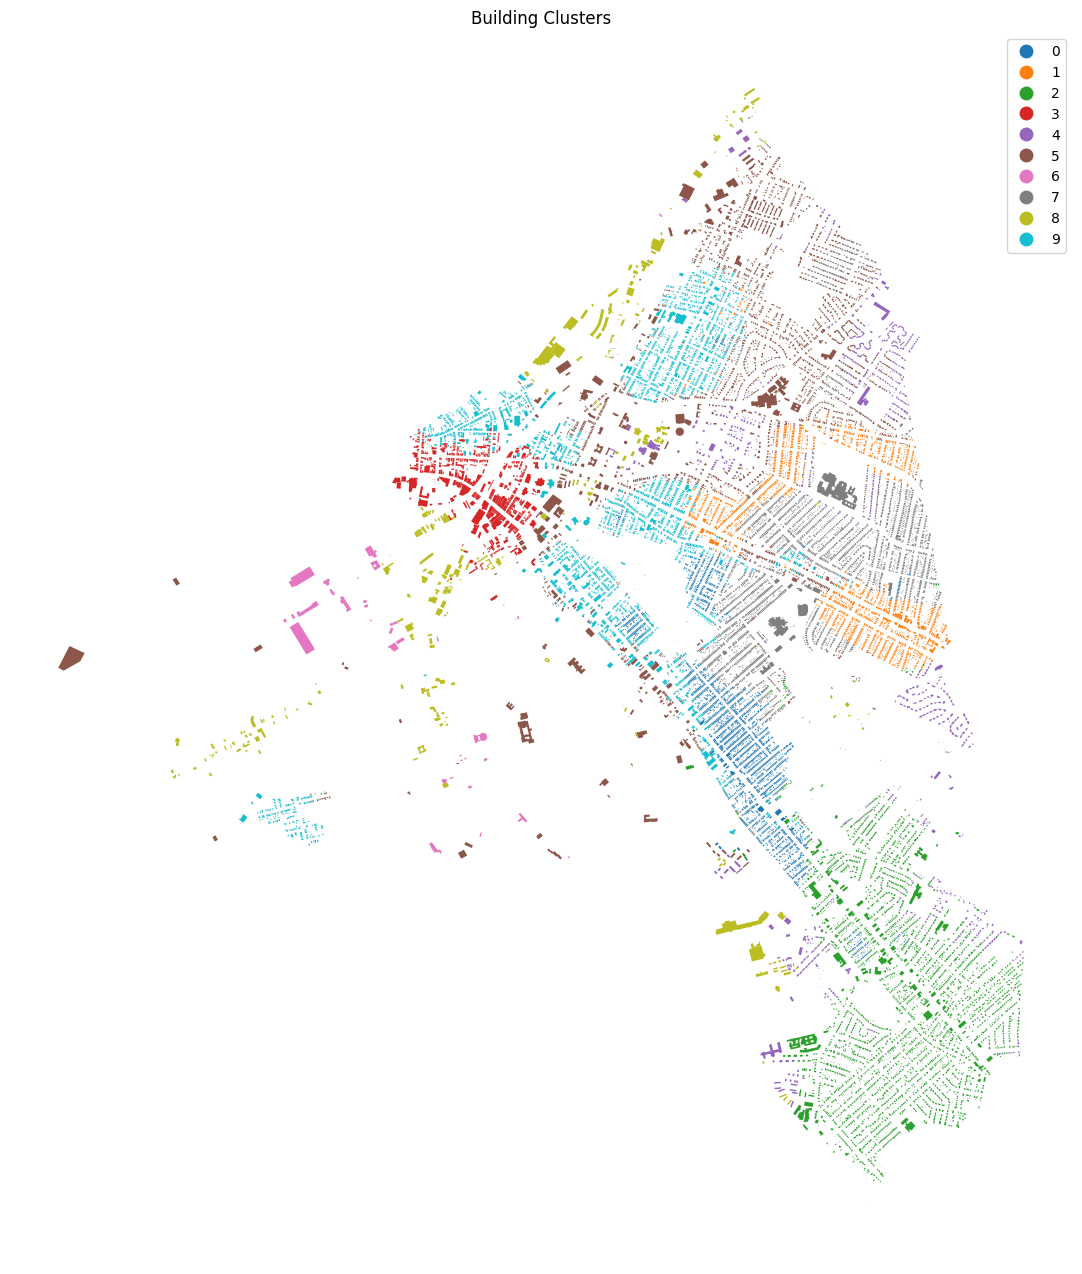

In [39]:
# map the results
# merge clusters with buildings
merged["cluster"] = cgram.labels[10].values
buildings["cluster"] = merged["cluster"]

# and plot
ax = buildings.plot(
    "cluster", categorical=True, figsize=(16, 16), legend=True
)
ax.set_axis_off()
ax.set_title("Building Clusters")

## More resouces
- Fleischmann, Martin, Simplified detection of urban types, https://docs.momepy.org/stable/examples/clustering.html#spatial-distribution
- Fleischmann M, Feliciotti A, Romice O and Porta S (2021) Methodological Foundation of a Numerical Taxonomy of Urban Form. Environment and Planning B: Urban Analytics and City Science, doi: 10.1177/23998083211059835